<img src="https://udemedellin.edu.co/wp-content/uploads/2022/10/logo_udemedellin2.png" width="30%">

<b>ESPECIALIZACIÓN EN CIENCIA DE DATOS E INGELIGENCIA ARTIFICIAL</b>

<strong>Fundamentos de Estadística para Ciencia de Datos</strong>

# Sesión 4 — Estadística descriptiva de datos categóricos

## Objetivos de aprendizaje

Al finalizar esta sesión serás capaz de:

- Calcular e interpretar frecuencias, proporciones, moda y tablas de contingencia para variables categóricas.
- Identificar variables de alta cardinalidad, entender los problemas que generan, y aplicar estrategias para reducirla (incluyendo un adelanto de codificación para machine learning).
- Detectar categorías atípicas o inconsistentes en los datos y aplicar estrategias de limpieza.
- Elegir el gráfico adecuado (barras, pastel, apiladas, Pareto) según la pregunta que se quiera responder, y explicar por qué.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import TargetEncoder

sns.set_theme(style="whitegrid", palette="deep")
%matplotlib inline

pd.set_option("display.precision", 3)

## 1. Repaso: variables categóricas

En sesiones anteriores vimos que las variables se pueden clasificar en cualitativas (nominal/ordinal) y cuantitativas (discreta/continua). Tambien vimos que estadísticos como la media, varianza, cuantiles, no aplican a una variable categórica. Esto debido a que requieren que los valores se puedan sumar, restar u ordenar numéricamente.

Esta sesión veremos qué se puede y no se puede calcular y graficar para datos categóricos. Adicional, veremos dos problemas prácticos muy comunes en ciencia de datos: la **alta cardinalidad** y las **categorías inconsistentes**.

## 2. Estadística descriptiva de datos categóricos

Para una variable categórica con categorías $c_1, \dots, c_k$, las cantidades básicas son:

$$n_j = \#\{x_i = c_j\}$$
$$p_j = \frac{n_j}{n}, \qquad \sum_{j=1}^{k} p_j = 1$$

donde $n_j$ es la frecuencia absoluta de la categoría $c_j$, y $p_j$ su frecuencia relativa. La **moda** es la categoría con mayor $n_j$, es la única medida de tendencia central que tiene sentido para datos categóricos.

In [2]:
titanic = sns.load_dataset("titanic")
titanic[["sex", "class", "embark_town", "who", "alive"]].head()

,sex,class,embark_town,who,alive
0,male,Third,Southampton,man,no
1,female,First,Cherbourg,woman,yes
2,female,Third,Southampton,woman,yes
3,female,First,Southampton,woman,yes
4,male,Third,Southampton,man,no


In [3]:
freq_class = titanic["class"].value_counts().to_frame(name="FA")
freq_class["FR"] = freq_class["FA"] / len(titanic)
freq_class["pct (%)"] = freq_class["FR"] * 100
freq_class

,FA,FR,pct (%)
class,,,
Third,491,0.551,55.107
First,216,0.242,24.242
Second,184,0.207,20.651


In [4]:
print(f"Moda de 'class': {titanic['class'].mode()[0]}")

Moda de 'class': Third


### Relación entre variables categóricas: Tabla de contingencia

Cuando quieres describir la relación entre **dos** variables categóricas, se usan tablas de contingencia. Esta cuenta cuántas observaciones caen en cada combinación de categorías.

In [5]:
contingencia = pd.crosstab(titanic["class"], titanic["survived"])
contingencia

survived,0,1
class,,
First,80,136
Second,97,87
Third,372,119


In [6]:
# Porcentaje de sobrevivientes DENTRO de cada clase (normalize="index" normaliza por fila)
pd.crosstab(titanic["class"], titanic["survived"], normalize="index") * 100

survived,0,1
class,,
First,37.037,62.963
Second,52.717,47.283
Third,75.764,24.236


Normalizar por fila (`normalize="index"`) responde "¿qué porcentaje de esta clase sobrevivió?", en cambio, normalizar por columna (`normalize="columns"`) respondería "de los sobrevivientes, ¿qué porcentaje venía de cada clase?" Son preguntas distintas, elige según lo que quieras comunicar.

**Ejercicio:** construye la tabla de frecuencias (FA, FR, %) de `embark_town` e identifica su moda. Luego construye la tabla de contingencia entre `embark_town` y `class`, normalizada por fila.

In [7]:
# Ejercicio: estadística descriptiva categórica
# TODO 1: tabla de frecuencias (FA, FR, %) de embark_town + moda
# TODO 2: tabla de contingencia embark_town x class, normalizada por fila

## 3. Variables de alta cardinalidad

Una variable categórica tiene **alta cardinalidad** cuando el número de categorías distintas es grande, en particular, cuando se acerca al número de observaciones. Una forma simple de medirlo es el **ratio de cardinalidad**:

$$\text{ratio} = \frac{\#\text{categorías únicas}}{n}$$

Problemas que genera:

- **Visualización**: no caben todas las categorías en un gráfico legible.
- **Estadística por grupo**: cada categoría individual queda con muy pocas observaciones, lo que hace poco confiable cualquier estadístico calculado dentro de ese grupo.
- **Machine learning**: codificar con one-hot genera una columna por categoría con cientos o miles de categorías, el número de columnas explota (maldición de la dimensionalidad) y la mayoría de esas columnas queda casi siempre en cero.

In [8]:
mpg = sns.load_dataset("mpg")

n = len(mpg)

n_unique_name = mpg["name"].nunique()
n_unique_origin = mpg["origin"].nunique()

card_ratio_name = n_unique_name / n
card_ratio_origin = n_unique_origin / n

print(f"'name': {n_unique_name} categorías únicas de {n} observaciones (ratio = {card_ratio_name:.2f})")
print(f"'origin': {n_unique_origin} categorías únicas de {n} observaciones (ratio = {card_ratio_origin:.2f})")

'name': 305 categorías únicas de 398 observaciones (ratio = 0.77)
'origin': 3 categorías únicas de 398 observaciones (ratio = 0.01)


`name` tiene un ratio muy cercano a 1: la gran mayoría de los autos tienen un nombre distinto, así que como categoría es casi un identificador, es decir, es poco útil para agrupar o modelar. Una estrategia común es **derivar** una variable de menor cardinalidad con más significado aquí, por ejemplo, el fabricante el cual es la primera palabra del nombre.

In [9]:
mpg["manufacturer"] = mpg["name"].str.split().str[0]

n_unique_manufacturer = mpg['manufacturer'].nunique()
card_ratio_manufacturer = n_unique_manufacturer / mpg.shape[0]

print(f"'manufacturer': {n_unique_manufacturer} categorías únicas (ratio: {card_ratio_manufacturer:.02f})")
mpg["manufacturer"].value_counts()

'manufacturer': 37 categorías únicas (ratio: 0.09)


manufacturer
ford             51
chevrolet        43
plymouth         31
amc              28
dodge            28
toyota           25
datsun           23
buick            17
pontiac          16
volkswagen       15
honda            13
mercury          11
oldsmobile       10
mazda            10
peugeot           8
fiat              8
audi              7
chrysler          6
volvo             6
vw                6
renault           5
saab              4
opel              4
subaru            4
chevy             3
bmw               2
maxda             2
mercedes-benz     2
cadillac          2
hi                1
toyouta           1
chevroelt         1
capri             1
mercedes          1
vokswagen         1
triumph           1
nissan            1
Name: count, dtype: int64

Bajan de 305 a 37 categorías: mucho más manejable.
### Otra estrategia: agrupar categorías poco frecuentes ("otros")

Cuando no hay una forma natural de derivar una categoría más general, se puede agrupar directamente por frecuencia. La estretegía consiste en quedarse con las $k$ categorías más comunes y agrupar el resto en la categoría "otros".

In [10]:
top_k = 8
categorias_top = mpg["manufacturer"].value_counts().nlargest(top_k).index
mpg["manufacturer_agrupado"] = mpg["manufacturer"].where(mpg["manufacturer"].isin(categorias_top), other="Otros")
mpg["manufacturer_agrupado"].value_counts()

manufacturer_agrupado
Otros        152
ford          51
chevrolet     43
plymouth      31
amc           28
dodge         28
toyota        25
datsun        23
buick         17
Name: count, dtype: int64

### Codificar variables de alta cardinalidad para machine learning

Si el objetivo no es solo describir sino **modelar**, one-hot encoding no es la única opción. Dos alternativas comunes:

**Codificación por frecuencia:** reemplaza cada categoría por su frecuencia relativa. Convierte la variable categórica en una columna numérica sin agregar dimensiones, a costa de perder la identidad de la categoría (dos categorías con la misma frecuencia quedan indistinguibles).

In [11]:
frecuencia_manufacturer = mpg["manufacturer"].value_counts(normalize=True)
mpg["manufacturer_freq_encoded"] = mpg["manufacturer"].map(frecuencia_manufacturer)
mpg[["manufacturer", "manufacturer_freq_encoded"]].head()

,manufacturer,manufacturer_freq_encoded
0,chevrolet,0.108
1,buick,0.043
2,plymouth,0.078
3,amc,0.070
4,ford,0.128


**Codificación por target (*target encoding*):** reemplaza cada categoría por un resumen (típicamente la media) de la variable objetivo para esa categoría. Es más informativa que la codificación por frecuencia. Sin embargo, hay que tener cuidado de usar directamente la media de entrenamiento puesto que puede haber *data leakage* si no se hace con cuidado. La librería `scikit-learn` lo implementa con validación cruzada interna: por eso, dentro de `fit_transform`, filas con la misma categoría pueden recibir valores distintos (cada una se codifica con un modelo que no la vio). En `transform` sobre datos nuevos (p. ej. el set de test) ya no hay cross-fitting: cada categoría recibe un único valor fijo, aprendido en el `fit` sobre train.

In [38]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(mpg, test_size=0.2, random_state=42)

encoder = TargetEncoder(target_type="continuous", random_state=42)
train_target_encoded = encoder.fit_transform(train[["manufacturer"]], train["mpg"])
test_target_encoded = encoder.transform(test[["manufacturer"]])

pd.DataFrame({
    "manufacturer": test["manufacturer"],
    "target_encoded (rendimiento promedio)": test_target_encoded.ravel(),
}).drop_duplicates().sort_values("target_encoded (rendimiento promedio)", ascending=False).head(10)

/Users/marduque/nico_projects/esp_estadistica_202607/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


,manufacturer,target_encoded (rendimiento promedio)
394,vw,36.394
198,honda,33.140
312,datsun,30.678
377,mazda,30.103
114,fiat,29.629
77,volkswagen,29.496
84,toyota,28.606
141,audi,26.054
78,peugeot,24.050
82,toyouta,23.608


Una tercera alternativa para cardinalidades extremas (miles de categorías) es el *hashing trick* (`sklearn.feature_extraction.FeatureHasher`): mapea las categorías a un número fijo de columnas mediante una función hash, sin necesidad de conocer de antemano cuántas categorías existen. No se usa aquí porque 37 categorías no lo justifican, pero vale la pena conocerlo para datasets con miles de categorías (p. ej. IDs de producto).

| Estrategia | Cuándo usarla | Riesgo principal |
|---|---|---|
| Agrupar en "Otros" / derivar categoría | Exploración y modelos simples | Pierde granularidad de las categorías poco frecuentes |
| Codificación por frecuencia | Modelos que aceptan variables numéricas, cardinalidad moderada-alta | Categorías distintas con igual frecuencia quedan indistinguibles |
| Codificación por objetivo (target encoding) | Cardinalidad alta, se busca máxima señal predictiva | Data leakage si no se implementa con validación cruzada |
| Hashing | Cardinalidad extrema (miles+) o categorías desconocidas de antemano | Colisiones (dos categorías distintas caen en la misma columna) |

**Ejercicio:** agrupa `manufacturer` dejando solo las 5 categorías más frecuentes (el resto como "Otros"), y calcula qué porcentaje de las observaciones originales quedó en "Otros".

In [13]:
# Ejercicio: reducir cardinalidad
# TODO 1: agrupa manufacturer dejando el top 5 + "Otros"
# TODO 2: calcula qué % de las observaciones quedó en "Otros"

## 4. Categorías atípicas o inconsistentes

Conviene distinguir dos problemas distintos que suelen mezclarse bajo el nombre "atípicos" en datos categóricos:

- **Categorías raras pero válidas** (cola larga): ocurren genuinamente, solo que con poca frecuencia (p. ej. un fabricante con un solo modelo en el dataset). No son errores — es el mismo problema de alta cardinalidad que ya tratamos en la sección 3.
- **Categorías inconsistentes**: la misma categoría real, escrita de formas distintas por errores de digitación, mayúsculas/minúsculas, abreviaciones o inconsistencias en la fuente de datos. Estas sí son errores y deben corregirse antes de cualquier análisis, o vas a subestimar la frecuencia real de esa categoría (y sobreestimar la cardinalidad).

El primer paso para detectarlas es inspeccionar las categorías únicas ordenadas alfabéticamente: los duplicados por inconsistencia suelen quedar muy cerca entre sí.

In [14]:
sorted(mpg["manufacturer"].unique())

['amc',
 'audi',
 'bmw',
 'buick',
 'cadillac',
 'capri',
 'chevroelt',
 'chevrolet',
 'chevy',
 'chrysler',
 'datsun',
 'dodge',
 'fiat',
 'ford',
 'hi',
 'honda',
 'maxda',
 'mazda',
 'mercedes',
 'mercedes-benz',
 'mercury',
 'nissan',
 'oldsmobile',
 'opel',
 'peugeot',
 'plymouth',
 'pontiac',
 'renault',
 'saab',
 'subaru',
 'toyota',
 'toyouta',
 'triumph',
 'vokswagen',
 'volkswagen',
 'volvo',
 'vw']

Varios fabricantes aparecen repetidos por inconsistencias reales en los datos:

- `chevrolet` / `chevy` (abreviación) / `chevroelt` (error de digitación)
- `volkswagen` / `vw` (abreviación) / `vokswagen` (error de digitación)
- `toyota` / `toyouta` (error de digitación)
- `mazda` / `maxda` (error de digitación)
- `mercedes` / `mercedes-benz` (inconsistencia de la fuente original: un registro usa espacio y otro guion, y `str.split()` los separó de forma distinta)

Y dos casos que **no** se resuelven con un simple mapeo de alias, porque el problema no es de escritura sino del método de extracción: `hi 1200d` (International Harvester, un fabricante cuyo nombre no aparece tal cual en el texto) y `capri ii` (no es un fabricante, es un modelo — el nombre completo no incluía el fabricante). Para estos dos, corregir requiere revisar el dato original, no solo normalizar texto.

In [15]:
alias_fabricante = {
    "chevy": "chevrolet",
    "chevroelt": "chevrolet",
    "vw": "volkswagen",
    "vokswagen": "volkswagen",
    "toyouta": "toyota",
    "maxda": "mazda",
    "mercedes": "mercedes-benz",
}

mpg["manufacturer_limpio"] = mpg["manufacturer"].replace(alias_fabricante)
print(f"Categorías antes de limpiar: {mpg['manufacturer'].nunique()}")
print(f"Categorías después de limpiar: {mpg['manufacturer_limpio'].nunique()}")

Categorías antes de limpiar: 37
Categorías después de limpiar: 30


**Ejercicio 3:** identifica manualmente a qué fabricante corresponden `hi` y `capri` (puedes inspeccionar `mpg.loc[mpg["manufacturer"].isin(["hi", "capri"]), "name"]`), y decide si tiene sentido agregarlos a `alias_fabricante`.

In [16]:
# Ejercicio 3: resolver los casos ambiguos "hi" y "capri"
# TODO: inspecciona mpg.loc[mpg["manufacturer"].isin(["hi", "capri"]), "name"] y decide qué hacer con cada uno

## 5. Visualización de datos categóricos

A diferencia de los histogramas (sesión 2), que muestran cómo se distribuye una variable continua, aquí graficamos **conteos o proporciones por categoría**. El gráfico correcto depende de cuántas categorías tengas y de qué pregunta quieras responder.

### 5.1 Gráfico de barras

La opción por defecto para comparar magnitudes entre categorías: la longitud de cada barra se compara sobre una misma escala, algo que el ojo humano hace con mucha precisión. Úsalo con pocas categorías (hasta 6-8) y etiquetas cortas; si la variable es ordinal (como `class`), respeta su orden natural en vez de ordenar por frecuencia.

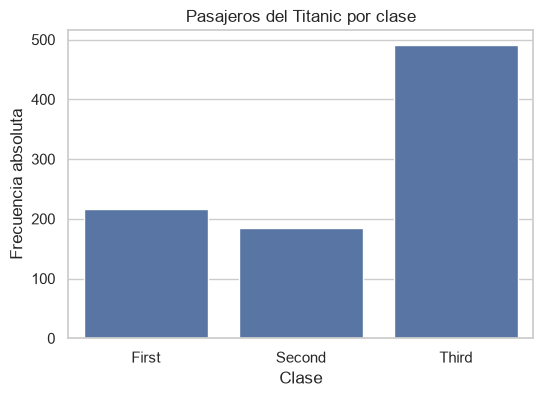

In [17]:
orden_class = ["First", "Second", "Third"]

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=titanic, x="class", order=orden_class, ax=ax)
ax.set_title("Pasajeros del Titanic por clase")
ax.set_xlabel("Clase")
ax.set_ylabel("Frecuencia absoluta")
plt.show()

### 5.2 Gráfico de barras horizontal

Cuando hay muchas categorías o las etiquetas son largas, un gráfico vertical obliga a rotar el texto y se vuelve difícil de leer. Girar las barras (y ordenarlas por frecuencia) resuelve ambos problemas:

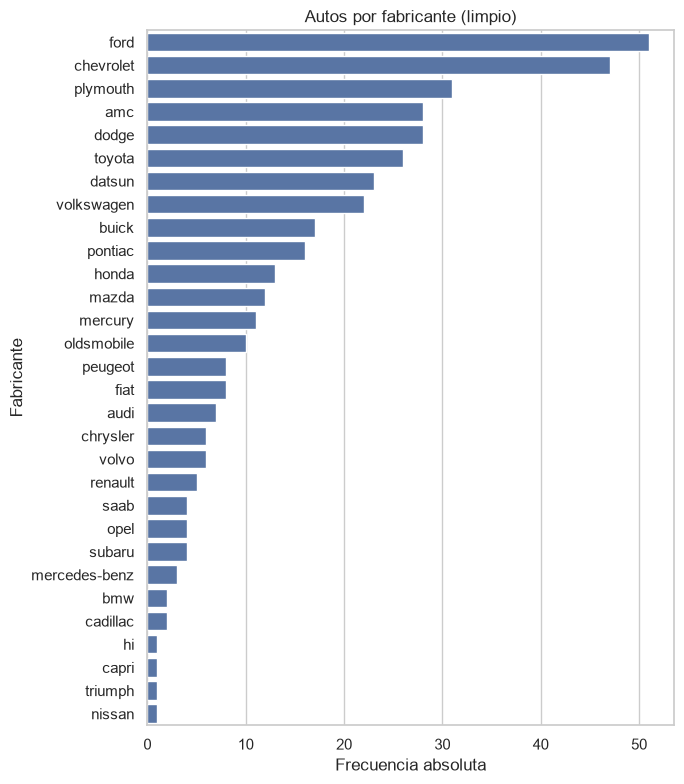

In [18]:
conteo_manufacturer = mpg["manufacturer_limpio"].value_counts()

fig, ax = plt.subplots(figsize=(7, 8))
sns.barplot(x=conteo_manufacturer.values, y=conteo_manufacturer.index, ax=ax, orient="h")
ax.set_title("Autos por fabricante (limpio)")
ax.set_xlabel("Frecuencia absoluta")
ax.set_ylabel("Fabricante")
plt.tight_layout()
plt.show()

### 5.3 Gráfico de pastel (pie chart)

Útil **solo** para mostrar composición parte-todo con pocas categorías (idealmente ≤ 5). El motivo es perceptual, no estético: comparar ángulos o áreas (lo que exige un pastel) es una tarea menos precisa para el ojo humano que comparar longitudes sobre una misma escala (lo que exige un gráfico de barras) — un resultado documentado en investigación de percepción gráfica (Cleveland & McGill, 1984). Por eso, ante la duda, un gráfico de barras casi siempre comunica mejor que un pastel.

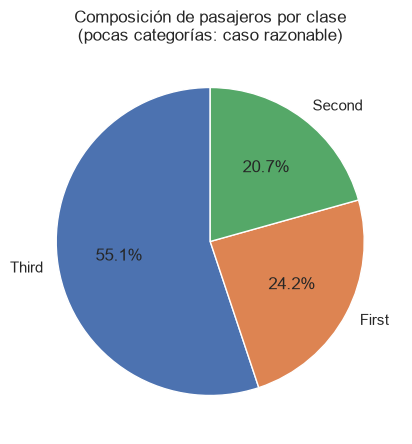

In [19]:
conteo_class = titanic["class"].value_counts()

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(conteo_class, labels=conteo_class.index, autopct="%1.1f%%", startangle=90)
ax.set_title("Composición de pasajeros por clase\n(pocas categorías: caso razonable)")
plt.show()

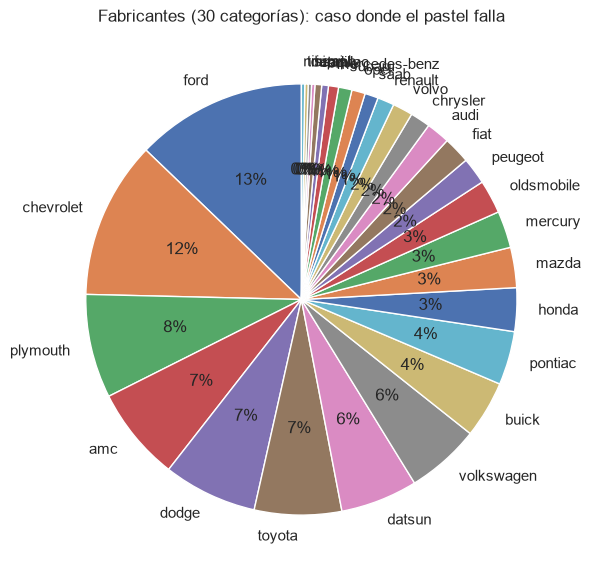

In [20]:
# Mismo tipo de gráfico, pero con muchas categorías: se vuelve ilegible
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(conteo_manufacturer, labels=conteo_manufacturer.index, autopct="%1.0f%%", startangle=90)
ax.set_title("Fabricantes (30 categorías): caso donde el pastel falla")
plt.show()

### 5.4 Gráfico de barras apiladas

Para comparar la composición de una variable categórica **entre grupos** definidos por otra variable categórica (dos variables a la vez):

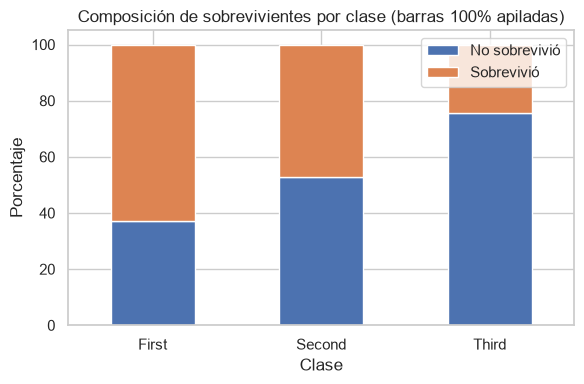

In [21]:
composicion = pd.crosstab(titanic["class"], titanic["survived"], normalize="index") * 100
composicion.columns = ["No sobrevivió", "Sobrevivió"]

composicion.plot(kind="bar", stacked=True, figsize=(6, 4))
plt.title("Composición de sobrevivientes por clase (barras 100% apiladas)")
plt.xlabel("Clase")
plt.ylabel("Porcentaje")
plt.xticks(rotation=0)
plt.legend(title=None)
plt.tight_layout()
plt.show()

### 5.5 Gráfico de Pareto

Combina un gráfico de barras (ordenado descendente) con una línea de porcentaje acumulado. Sirve para **priorizar**: identificar cuántas categorías explican la mayoría del total — la misma pregunta que resolvimos "a mano" en la sección 3 al decidir un top-$k$ para agrupar en "Otros".

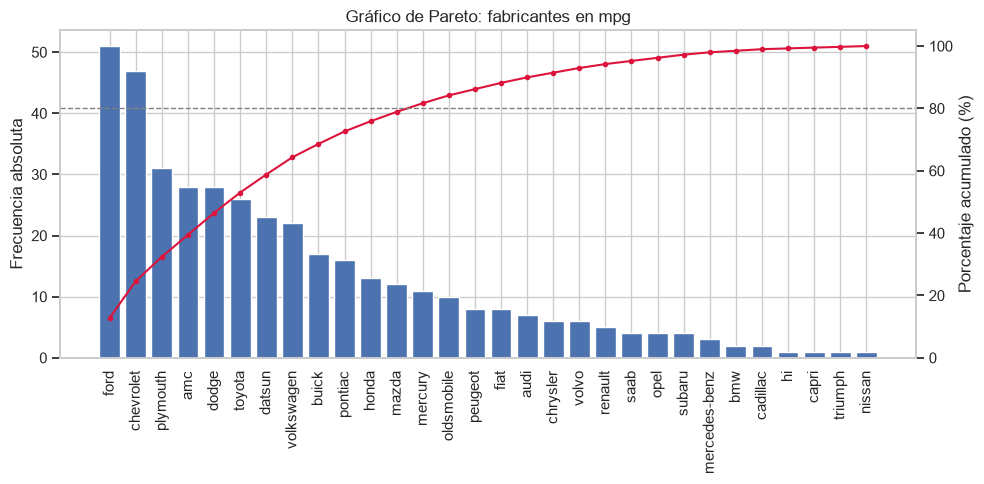

In [22]:
conteo = mpg["manufacturer_limpio"].value_counts()
porcentaje_acumulado = conteo.cumsum() / conteo.sum() * 100

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(conteo.index, conteo.values, color="#4C72B0")
ax1.set_ylabel("Frecuencia absoluta")
ax1.set_xticks(range(len(conteo.index)))
ax1.set_xticklabels(conteo.index, rotation=90)

ax2 = ax1.twinx()
ax2.plot(conteo.index, porcentaje_acumulado.values, color="crimson", marker="o", markersize=3)
ax2.set_ylabel("Porcentaje acumulado (%)")
ax2.set_ylim(0, 105)
ax2.axhline(80, color="gray", linestyle="--", linewidth=1)
ax2.grid(False)

ax1.set_title("Gráfico de Pareto: fabricantes en mpg")
plt.tight_layout()
plt.show()

### Resumen: cuándo usar cada gráfico

| Gráfico | Mejor para | Evitar cuando |
|---|---|---|
| Barras (vertical) | Comparar magnitudes entre pocas categorías | Muchas categorías o etiquetas largas |
| Barras horizontales | Muchas categorías o etiquetas largas | Pocas categorías (no aporta ventaja sobre el vertical) |
| Pastel | Composición parte-todo con ≤ 5 categorías | Comparaciones precisas, más de 5 categorías, comparar varios pasteles entre sí |
| Barras apiladas (100%) | Comparar composición entre grupos (2 variables categóricas) | Muchas subcategorías (se vuelve ilegible) |
| Pareto | Priorizar: qué pocas categorías explican la mayoría del total | La proporción acumulada no es relevante para la pregunta |

*Otra alternativa al pastel con muchas categorías es el **treemap** (rectángulos anidados proporcionales a la frecuencia); no lo implementamos aquí porque requiere una librería adicional (`squarify`) fuera del stack de este curso.*

**Ejercicio 4:** construye un gráfico de barras horizontal para `embark_town`, ordenado de mayor a menor frecuencia.

In [23]:
# Ejercicio 4: barras horizontales
# TODO: gráfico de barras horizontal de embark_town, ordenado por frecuencia descendente

## Cierre

**Ideas clave de hoy:**

- Para variables categóricas, las medidas descriptivas se reducen a frecuencias, proporciones y moda; la relación entre dos categóricas se resume con una tabla de contingencia.
- La alta cardinalidad no es solo un problema de visualización: afecta la confiabilidad de estadísticos por grupo y explota el número de columnas en one-hot encoding. Agrupar, derivar una categoría de menor cardinalidad, o usar codificación por frecuencia/objetivo son estrategias distintas con distintos trade-offs.
- Las categorías inconsistentes (mismo valor real, distinta escritura) inflan artificialmente la cardinalidad y deben limpiarse antes de cualquier análisis — `sorted(serie.unique())` es el primer diagnóstico.
- La elección del gráfico no es estética: depende de cuántas categorías hay y de qué comparación (magnitud vs. composición vs. priorización) quieres comunicar.

**Preguntas de reflexión para la próxima sesión:**

1. En el crosstab `class` x `survived`, ¿la diferencia de proporciones entre clases te parece "grande"? ¿Cómo decidirías si es estadísticamente significativa?
2. Piensa en una variable categórica de tu propio trabajo/tesis: ¿tiene alta cardinalidad? ¿Categorías inconsistentes?

**Próxima sesión:** a definir — posible continuación con pruebas de hipótesis/intervalos de confianza, o correlación y relaciones entre variables numéricas.